# Clean BG / Fermi Plots

This notebook builds a two-panel figure:
- panel a: three occupation snapshots from a BG-like run
- panel b: effective temperature and fit SSE versus time for a BG-like run and a Fermi-like run

The default comparison uses a matched pair with the same `T_bath`, `alpha`, and `p_c`, differing only in `eta`.

In [1]:
using DelimitedFiles
import PyPlot as plt

In [48]:
plt.rc("text", usetex=true)
plt.rc("font", family="serif")
plt.rc("text.latex", preamble=raw"\usepackage{amsmath}")
fs = 21
plt.rc("font", size=fs)
plt.rc("axes", labelsize=fs, titlesize=fs)
plt.rc("xtick", labelsize=fs)
plt.rc("ytick", labelsize=fs)
plt.rc("legend", fontsize=fs)

letter = ["("*string(c)*")" for c in 'a':'z'];

In [87]:
base_dir = pwd()
analysis_dir = joinpath(base_dir, "analysis", "fermi_fit_t60")
occupations_dir = joinpath(base_dir, "DOPE_v3", "projects", "2026-04-08-structured-chain-grid-long-t100", "data", "occupations")

timeseries_file = joinpath(analysis_dir, "fermi_fit_timeseries.csv")

# Default matched pair: same T_bath, alpha, and p_c; different eta.
bg_file = "run_026_T0p050_alpha0p500_eta0p050_pc0p500.csv"
fermi_file = "run_035_T0p050_alpha0p500_eta0p500_pc1p000.csv"

# Editable snapshot times for panel a.
snapshot_times = [0, 20, 60]

3-element Vector{Int64}:
  0
 20
 60

In [88]:
timeseries_raw, timeseries_header = readdlm(timeseries_file, ',', header=true)
timeseries_header = vec(timeseries_header)

run_col = findfirst(==("run"), timeseries_header)
file_col = findfirst(==("file"), timeseries_header)
time_col = findfirst(==("time"), timeseries_header)
teff_col = findfirst(==("teff_fit"), timeseries_header)
sse_col = findfirst(==("sse_fit"), timeseries_header)

bg_mask = vec(timeseries_raw[:, file_col] .== bg_file)
fermi_mask = vec(timeseries_raw[:, file_col] .== fermi_file)

bg_ts = timeseries_raw[bg_mask, :]
fermi_ts = timeseries_raw[fermi_mask, :]

bg_t = Float64.(bg_ts[:, time_col])
bg_teff = Float64.(bg_ts[:, teff_col])
bg_sse = Float64.(bg_ts[:, sse_col])

fermi_t = Float64.(fermi_ts[:, time_col])
fermi_teff = Float64.(fermi_ts[:, teff_col])
fermi_sse = Float64.(fermi_ts[:, sse_col])

bg_occ_raw, bg_occ_header = readdlm(joinpath(occupations_dir, bg_file), ',', header=true)
bg_occ_header = vec(bg_occ_header)

occ_times = Float64.(bg_occ_raw[:, 1])
occ_values = Float64.(bg_occ_raw[:, 2:end])
nk = size(occ_values, 2)
k = collect(LinRange(-pi, pi, nk))

sidx = [argmin(abs.(occ_times .- t)) for t in snapshot_times]
snapshot_actual_times = occ_times[sidx]

bg_label = replace(replace(bg_file, "run_014_" => ""), ".csv" => "")
fermi_label = replace(replace(fermi_file, "run_022_" => ""), ".csv" => "")

"run_035_T0p050_alpha0p500_eta0p500_pc1p000"

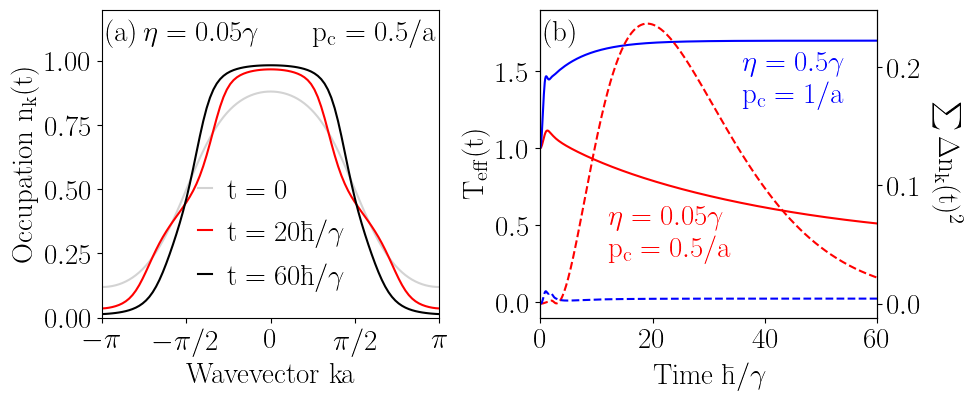

In [91]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.3)

ax[1].plot(k, occ_values[sidx[1], :], "lightgrey", label=raw"$\rm t="*string(snapshot_times[1])*raw"$")
ax[1].plot(k, occ_values[sidx[2], :], "r", label=raw"$\rm t="*string(snapshot_times[2])*raw"\hbar/\gamma$")
ax[1].plot(k, occ_values[sidx[3], :], "k", label=raw"$\rm t="*string(snapshot_times[3])*raw"\hbar/\gamma$")

ax_sse = ax[2].twinx()

ax[2].plot(bg_t, bg_teff, "r")
ax[2].plot(fermi_t, fermi_teff, "b")
ax_sse.plot(bg_t, bg_sse, "r--")
ax_sse.plot(fermi_t, fermi_sse, "b--")

ax[1].set_xlabel(raw"$\rm Wavevector \ ka$", fontsize=fs)
ax[1].set_ylabel(raw"$\rm Occupation \ n_k(t)$", fontsize=fs)
ax[1].set_xlim(-pi, pi)
ax[1].set_ylim(0, 1.2)
ax[1].set_xticks([-pi, -pi/2, 0.0, pi/2, pi])
ax[1].set_xticklabels([raw"$-\pi$", raw"$-\pi/2$", raw"$0$", raw"$\pi/2$", raw"$\pi$"])
ax[1].legend(frameon=false, loc="lower center", handlelength=0.5, handletextpad=0.5)

ax[1].text(x=0.12, y=0.9, s=raw"$\rm \eta = 0.05\gamma \qquad p_c=0.5/a $", transform=ax[1].transAxes, fontsize=fs)

ax[2].set_xlabel(raw"$\rm Time \ \hbar/\gamma$", fontsize=fs)
ax[2].set_ylabel(raw"$\rm T_{eff}(t)$", fontsize=fs)
ax[2].set_xlim(0, 60)
ax[2].set_ylim(-0.1, 1.9)

ax[2].text(x=0.2, y=0.3, s=raw"$\rm \eta = 0.05\gamma$", transform=ax[2].transAxes, fontsize=fs, color="r")
ax[2].text(x=0.2, y=0.2, s=raw"$\rm p_c=0.5/a$", transform=ax[2].transAxes, fontsize=fs, color="r")
ax[2].text(x=0.6, y=0.8, s=raw"$\rm \eta = 0.5\gamma$", transform=ax[2].transAxes, fontsize=fs, color="b")
ax[2].text(x=0.6, y=0.7, s=raw"$\rm p_c=1/a$", transform=ax[2].transAxes, fontsize=fs, color="b")

ax_sse.set_ylabel(raw"$\rm \sum \Delta n_k(t)^2$", fontsize=fs, rotation=-90, labelpad=30)

for (i,a) in enumerate(ax)
    a.text(x=0.01, y=0.9, s=letter[i], transform=a.transAxes, fontsize=fs)
end

fig.align_labels()

fig.savefig("chain_dissipative.pdf", bbox_inches="tight")